## Models

**Goal**: Prepare dataset for ML modelling and start modelling

**Issues**:
* Encode the data_type and data_subject_type features
* Validate within the train set

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score, silhouette_score
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, train_test_split, cross_validate, GridSearchCV
from catboost import CatBoostClassifier
import numpy as np
from kmodes.kmodes import KModes
from sklearn.cluster import KMeans


In [3]:
# CSV file path
DF_HEALTH_PATH = "new-data-security-incident-trends-health-sector.csv"
# Target feature
TARGET_COL = "decision_taken"
# Multilabel columns contain a comma separated list of values and need multi label encoding
MULTILABEL_COLS = ["data_subject_type", "data_type"]
# Categorical columns are single value and need one hot encoding
CATEGORICAL_COLS = ["incident_category", "incident_type", "no_data_subjects_affected", "time_taken_to_report"]
# All feature columns
FEATURE_COLS = MULTILABEL_COLS + CATEGORICAL_COLS

In [4]:
# Load the preprocessed dataset
df = pd.read_csv(DF_HEALTH_PATH)

# Initial check for null values and data types - columns are int64 and object, no nulls
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9250 entries, 0 to 9249
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   year                       9250 non-null   int64 
 1   quarter                    9250 non-null   object
 2   data_subject_type          9250 non-null   object
 3   data_type                  9250 non-null   object
 4   decision_taken             9250 non-null   object
 5   incident_category          9250 non-null   object
 6   incident_type              9250 non-null   object
 7   no_data_subjects_affected  9250 non-null   object
 8   time_taken_to_report       9250 non-null   object
dtypes: int64(1), object(8)
memory usage: 650.5+ KB


In [5]:
# define the train/ test period: train 2021 Q2 - 2024 Q1, test 2024 Q4 - 2025 Q1 & Q2
def is_test_split(row):
    return(row["year"] == 2025)
    
# temp column to check train vs test split
df["is_test"] = df.apply(is_test_split, axis=1)
print(df["is_test"].value_counts())

# split into train and test sets
df_train = df[df["is_test"] == False].reset_index(drop=True)
df_test = df[df["is_test"] == True].reset_index(drop=True)

# drop temp column but keep year and quarter for now to check distribution in train vs test sets
df = df.drop(columns=["is_test"])

# drop year, quarter and is_test columns for modeling
df_train = df_train.drop(columns=["is_test"])
df_test = df_test.drop(columns=["is_test"]) 

# summary of years and quarters in train vs test sets
print("\nTraining set:\n", df_train[["year", "quarter"]].drop_duplicates().sort_values(["year", "quarter"]))
print("\nTest set:\n", df_test[["year", "quarter"]].drop_duplicates().sort_values(["year", "quarter"]))

is_test
False    7312
True     1938
Name: count, dtype: int64

Training set:
       year quarter
0     2021   Qtr 2
603   2021   Qtr 3
1035  2021   Qtr 4
1496  2022   Qtr 1
1917  2022   Qtr 2
2348  2022   Qtr 3
2829  2022   Qtr 4
3269  2023   Qtr 1
3723  2023   Qtr 2
4181  2023   Qtr 3
4682  2023   Qtr 4
5121  2024   Qtr 1
5631  2024   Qtr 2
6165  2024   Qtr 3
6766  2024   Qtr 4

Test set:
       year quarter
0     2025   Qtr 1
533   2025   Qtr 2
1032  2025   Qtr 3
1474  2025   Qtr 4


In [6]:
df_train.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7312 entries, 0 to 7311
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   year                       7312 non-null   int64 
 1   quarter                    7312 non-null   object
 2   data_subject_type          7312 non-null   object
 3   data_type                  7312 non-null   object
 4   decision_taken             7312 non-null   object
 5   incident_category          7312 non-null   object
 6   incident_type              7312 non-null   object
 7   no_data_subjects_affected  7312 non-null   object
 8   time_taken_to_report       7312 non-null   object
dtypes: int64(1), object(8)
memory usage: 514.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1938 entries, 0 to 1937
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   year            

In [7]:
# check counts and proportions of target variable (decision taken) in original, train and test sets
for name, subset in [("Original", df), ("Train", df_train), ("Test", df_test)]:
    counts = subset[TARGET_COL].value_counts()
    proportions = subset[TARGET_COL].value_counts(normalize=True).mul(100).round(1)
    summary = pd.DataFrame({f"{name} Count": counts, f"{name} Proportion (%)": proportions})
    print(f"\n{name} Set Decision Taken Summary:\n{summary}")


Original Set Decision Taken Summary:
                       Original Count  Original Proportion (%)
decision_taken                                                
Informal Action Taken            7670                     82.9
No Further Action                 982                     10.6
Investigation Pursued             598                      6.5

Train Set Decision Taken Summary:
                       Train Count  Train Proportion (%)
decision_taken                                          
Informal Action Taken         5834                  79.8
No Further Action              910                  12.4
Investigation Pursued          568                   7.8

Test Set Decision Taken Summary:
                       Test Count  Test Proportion (%)
decision_taken                                        
Informal Action Taken        1836                 94.7
No Further Action              72                  3.7
Investigation Pursued          30                  1.5


In [8]:
# Encode multilabel columns using MultiLabelBinarizer
mlb_encoders = {}
mlb_train_dfs = []
mlb_test_dfs = []

for col in MULTILABEL_COLS:
    # split each cell of ", " to get a list of values for each row
    train_lists = df_train[col].str.split(", ")
    test_lists = df_test[col].str.split(", ")
    
    mlb = MultiLabelBinarizer()
    mlb.fit(train_lists) # fit on training data only to avoid data leakage
    mlb_encoders[col] = mlb # store encoder for later use on test set
    
    # transform both sets 
    train_encoded = pd.DataFrame(
        mlb.transform(train_lists),
        columns=[f"{col}__{cls}" for cls in mlb.classes_],
        index=df_train.index
    )
    
    test_encoded = pd.DataFrame(
        mlb.transform(test_lists),
        columns=[f"{col}__{cls}" for cls in mlb.classes_],
        index=df_test.index
    )
    
    # store the encoded dataframes for later concatenation
    mlb_train_dfs.append(train_encoded)
    mlb_test_dfs.append(test_encoded)
    
    # check how many unique labels were found and what they are
    print(f"{col}: {len(mlb.classes_)} unique labels found")
    print(f"Labels: {list(mlb.classes_)}\n")
    
    # checks to see how encoding looks
    #print(f"Encoded sample of {col} in training set:\n{train_encoded.head()}\n")
    #print(f"Encoded sample of {col} in test set:\n{test_encoded.head()}\n")
    

data_subject_type: 9 unique labels found
Labels: ['Children', 'Customers or prospective customers', 'Employees', 'Patients', 'Students', 'Subscribers', 'Unknown', 'Users', 'Vulnerable adults']

data_type: 16 unique labels found
Labels: ['Basic personal identifiers', 'Criminal convictions or offences', 'Data revealing racial or ethnic origin', 'Economic and financial data', 'Gender Reassignment Data', 'Genetic or biometric data', 'Health data', 'Identification data', 'Location data', 'Official documents', 'Political opinions', 'Religious or philosophical beliefs', 'Sex life data', 'Sexual orientation data', 'Trade union membership', 'Unknown']



In [10]:
# Encode the other categorical columns using OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe.fit(df_train[CATEGORICAL_COLS]) # fit on training data only to avoid data leakage

ohe_train = pd.DataFrame(
    ohe.transform(df_train[CATEGORICAL_COLS]),
    columns=ohe.get_feature_names_out(CATEGORICAL_COLS),
    index=df_train.index
)

ohe_test = pd.DataFrame(
    ohe.transform(df_test[CATEGORICAL_COLS]),
    columns=ohe.get_feature_names_out(CATEGORICAL_COLS),
    index=df_test.index
)

# check how many unique values were found for each column, 34 total
for col in CATEGORICAL_COLS:
    unique_cats = df_train[col].nunique()
    print(f"{col}: {unique_cats} unique values found")
    print(f"Labels: {list(ohe.categories_[CATEGORICAL_COLS.index(col)])}\n")

incident_category: 2 unique values found
Labels: ['Cyber', 'Non Cyber']

incident_type: 21 unique values found
Labels: ['Alteration of personal data', 'Brute Force', 'Data emailed to incorrect recipient', 'Data of wrong data subject shown in client portal', 'Data posted or faxed to incorrect recipient', 'Denial of service', 'Failure to redact', 'Failure to use bcc', 'Hardware/software misconfiguration', 'Incorrect disposal of hardware', 'Incorrect disposal of paperwork', 'Loss/theft of device containing personal data', 'Loss/theft of paperwork or data left in insecure location', 'Malware', 'Not Provided', 'Other cyber incident', 'Other non-cyber incident', 'Phishing', 'Ransomware', 'Unauthorised access', 'Verbal disclosure of personal data']

no_data_subjects_affected: 7 unique values found
Labels: ['1 to 9', '10 to 99', '100 to 1k', '100k and above', '10k to 100k', '1k to 10k', 'Unknown']

time_taken_to_report: 4 unique values found
Labels: ['24 hours to 72 hours', '72 hours to 1 week

In [12]:
# Concatenate the MLB and OHE encoded features
X_train = pd.concat(mlb_train_dfs + [ohe_train], axis=1)
X_test = pd.concat(mlb_test_dfs + [ohe_test], axis=1)

y_train = df_train[TARGET_COL]
y_test = df_test[TARGET_COL]

# Check the shapes of the encoded features and target variables
print("Encoded feature shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Target shapes:")
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# confirm no nulls in encoded features
#print("\nNull values in X_train:\n", X_train.isnull().sum())
#print("\nNull values in X_test:\n", X_test.isnull().sum())

Encoded feature shapes:
X_train: (7312, 59)
X_test: (1938, 59)
Target shapes:
y_train: (7312,)
y_test: (1938,)


In [11]:
# function for evaluation metrics 
CLASS_LABELS = sorted(df[TARGET_COL].unique()) # get sorted list of unique target labels for consistent labelling

def evaluate_model(model_name, y_true, y_pred):
    # model name, ground truth, predicted values
    
    print(f"{model_name} Evaluation")
    
    # Per class breakdown of precision, recall and f1 score
    print("Classification Report:")
    print(classification_report(y_true, y_pred, labels=CLASS_LABELS, zero_division=0))
    
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    
    # display confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_LABELS)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
    disp.plot(cmap=plt.cm.plasma, ax=ax, colorbar=False)
    ax.set_title(f"{model_name} Confusion Matrix", fontsize=14, fontweight='bold', pad=12)
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()
    
    # confusion matrix table
    cm_df = pd.DataFrame(cm, index=CLASS_LABELS, columns=CLASS_LABELS)
    print("Confusion Matrix:\n", cm_df)
    
    # return metrics to potentially store them for comparing models later on
    return {
        "model": model_name,
        "accuracy": round(acc, 4),
        "macro_f1": round(macro_f1, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4)
    }

In [12]:
# Setup for time series cross validation - NEED TO DO TUNING LATER
N_SPLITS = 5
RANDOM_STATE = 42
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

rf_cv = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# cross validate returns per fold scores for each metric
rf_cv_results = cross_validate(
    rf_cv,
    X_train,
    y_train,
    cv=tscv,
    scoring={
        "accuracy": "accuracy",
        "macro_f1": "f1_macro",
        "precision": "precision_macro",
        "recall": "recall_macro"
    },
    error_score="raise"
)

# Summarise CV results across folds - RF, CV SCORES, TSS, 5 Folds
rf_cv_summary = pd.DataFrame({
    metric.replace("test_", ""): scores
    for metric, scores in rf_cv_results.items()
    if metric.startswith("test_")
})

# Add mean and std rows to summary
rf_cv_summary.index = [f"Fold {i+1}" for i in range(N_SPLITS)]
rf_cv_summary.loc["Mean"] = rf_cv_summary.mean()
rf_cv_summary.loc["Std"] = rf_cv_summary.std()
print(rf_cv_summary.round(4).to_string())

        accuracy  macro_f1  precision  recall
Fold 1    0.7882    0.4629     0.5006  0.4521
Fold 2    0.7233    0.4695     0.4763  0.4730
Fold 3    0.7167    0.4406     0.4613  0.4298
Fold 4    0.7512    0.5040     0.4854  0.5411
Fold 5    0.7028    0.4237     0.4257  0.4581
Mean      0.7365    0.4602     0.4698  0.4708
Std       0.0303    0.0273     0.0255  0.0378


In [13]:
# Train final model on full training set
rf_final = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)
print("Random Forest trained on full training set:")
print(f"Features: {X_train.shape[1]}") #59
print(f"Rows: {X_train.shape[0]}") #6766


Random Forest trained on full training set:
Features: 59
Rows: 7312


Random Forest Evaluation
Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.96      0.83      0.89      1836
Investigation Pursued       0.02      0.10      0.03        30
    No Further Action       0.16      0.33      0.21        72

             accuracy                           0.80      1938
            macro avg       0.38      0.42      0.38      1938
         weighted avg       0.92      0.80      0.86      1938



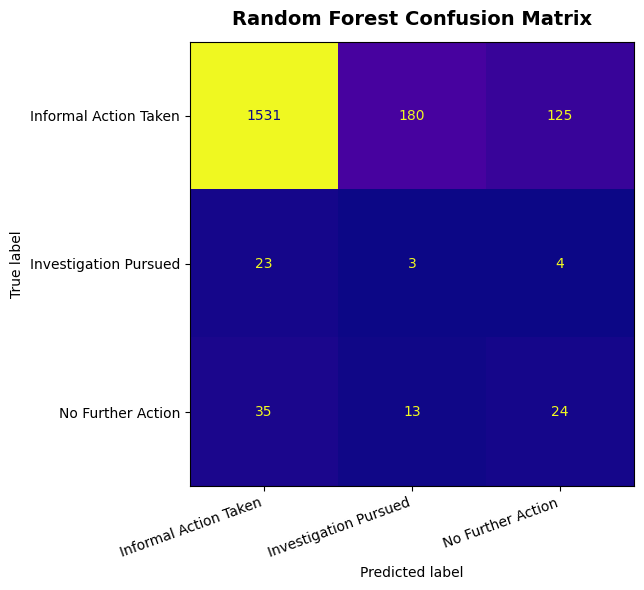

Confusion Matrix:
                        Informal Action Taken  Investigation Pursued  \
Informal Action Taken                   1531                    180   
Investigation Pursued                     23                      3   
No Further Action                         35                     13   

                       No Further Action  
Informal Action Taken                125  
Investigation Pursued                  4  
No Further Action                     24  


In [14]:
# Evaluate on test set
y_pred_rf = rf_final.predict(X_test)
rf_metrics = evaluate_model("Random Forest", y_test, y_pred_rf)

In [15]:
# Helper function to get original feature name from encoded column name

# mlb columns: original_col__label
# ohe columns: original_col_label
def get_original_feature(col_name):
    if "__" in col_name:
        return col_name.split("__")[0] # return mlb features
    for col in CATEGORICAL_COLS:
        if col_name.startswith(col):
            return col # for ohe features, get original column name
    return col_name # for mlb features, return as is

Feature Importance Summary (grouped by original feature):
         original_feature  importance
            incident_type      0.2773
        data_subject_type      0.1821
                data_type      0.1773
no_data_subjects_affected      0.1430
     time_taken_to_report      0.1242
        incident_category      0.0962


C:\Users\elsad\AppData\Local\Temp\ipykernel_19600\2157489678.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rf_feature_summary["original_feature"], rotation=45, ha='right')


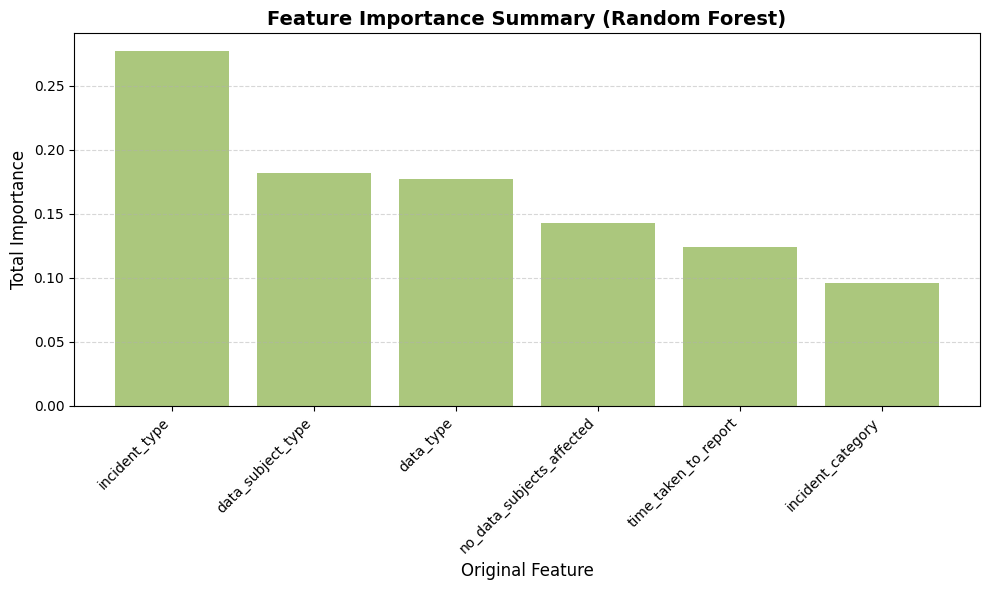

In [16]:
# Extract feature importance to see what columns the model is learning from
rf_importances_df = pd.DataFrame({
    "feature": X_train.columns, 
    "importance": rf_final.feature_importances_
}).sort_values(by="importance", ascending=False)

# add original feature column to importances df by applying the function to the feature names
rf_importances_df["original_feature"] = rf_importances_df["feature"].apply(get_original_feature)

# group by original feature and sum importance to see which features are important
rf_feature_summary = (
    rf_importances_df
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# table of feature importance summary
print("Feature Importance Summary (grouped by original feature):")
print(rf_feature_summary.round(4).to_string(index=False))

# bar chart of feature importance summary
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(rf_feature_summary["original_feature"], rf_feature_summary["importance"], color="#abc77d")
ax.set_title("Feature Importance Summary (Random Forest)", fontsize=14, fontweight='bold')
ax.set_xlabel("Original Feature", fontsize=12)
ax.set_ylabel("Total Importance", fontsize=12)
ax.set_xticklabels(rf_feature_summary["original_feature"], rotation=45, ha='right')
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [17]:
# tests for random forest 

# Test 1: predictions cover the full test set
assert len(y_pred_rf) == len(y_test), "Length of predictions does not match length of test labels"
print("1. Prediction count matches test label count")
print(f"\t{len(y_pred_rf)} predictions, {len(y_test)} test labels")

# Test 2: all predicted classes are valid known labels
assert set(y_pred_rf).issubset(set(CLASS_LABELS)), f"Predicted classes contain unknown labels: {set(y_pred_rf) - set(CLASS_LABELS)}"
print("2. All predicted classes are valid known labels")
print(f"\tSet of predicted classes: {set(y_pred_rf)}")

# Test 3: feature importances sum to approximately 1
assert abs(rf_importances_df["importance"].sum() - 1.0) < 1e-6, "Feature importances do not sum to approximately 1"
print("3. Feature importances sum to approximately 1")
print(f"\tSum of feature importances: {rf_importances_df['importance'].sum():.6f}")

# Test 4: model was trained on correct number of features
assert rf_final.n_features_in_ == X_train.shape[1], f"Model was trained on {rf_final.n_features_in_} features but expected {X_train.shape[1]}"
print("4. Model was trained on the correct number of features")
print(f"\t{rf_final.n_features_in_} features in model, {X_train.shape[1]} features in training data")

# Test 5: CV macro F1 mean us above a naive baseline 
mean_cv_f1 = rf_cv_results["test_macro_f1"].mean()
assert mean_cv_f1 > 0.2, f"Mean CV macro F1 score {mean_cv_f1:.4f} is not above the naive baseline of 0.2"
print(f"5. Mean CV macro F1 score {mean_cv_f1:.4f} is above the naive baseline of 0.2")
print(f"\tCV macro F1 scores across folds: {rf_cv_results['test_macro_f1']}")

# Test 6: no data leakage, test set rows aren't in the training set
train_periods = set(zip(df_train["year"], df_train["quarter"]))
test_periods = set(zip(df_test["year"], df_test["quarter"]))
assert train_periods.isdisjoint(test_periods), f"Data leakage detected: overlapping periods in train and test sets: {train_periods.intersection(test_periods)}"
print("6. No data leakage detected between train and test sets")
print(f"\t{sorted(train_periods)} training periods, {sorted(test_periods)} test periods")


1. Prediction count matches test label count
	1938 predictions, 1938 test labels
2. All predicted classes are valid known labels
	Set of predicted classes: {'Informal Action Taken', 'No Further Action', 'Investigation Pursued'}
3. Feature importances sum to approximately 1
	Sum of feature importances: 1.000000
4. Model was trained on the correct number of features
	59 features in model, 59 features in training data
5. Mean CV macro F1 score 0.4602 is above the naive baseline of 0.2
	CV macro F1 scores across folds: [0.46292037 0.46951355 0.44064443 0.5039868  0.42372251]
6. No data leakage detected between train and test sets
	[(2021, 'Qtr 2'), (2021, 'Qtr 3'), (2021, 'Qtr 4'), (2022, 'Qtr 1'), (2022, 'Qtr 2'), (2022, 'Qtr 3'), (2022, 'Qtr 4'), (2023, 'Qtr 1'), (2023, 'Qtr 2'), (2023, 'Qtr 3'), (2023, 'Qtr 4'), (2024, 'Qtr 1'), (2024, 'Qtr 2'), (2024, 'Qtr 3'), (2024, 'Qtr 4')] training periods, [(2025, 'Qtr 1'), (2025, 'Qtr 2'), (2025, 'Qtr 3'), (2025, 'Qtr 4')] test periods


In [18]:
# CV CatBoost on training set - NEED TO DO TUNING LATER
cb = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    auto_class_weights="Balanced",
    random_state=RANDOM_STATE,
    verbose=0
)

cb_cv_results = cross_validate(
    cb,
    X_train,
    y_train,
    cv=tscv,
    scoring={
        "accuracy": "accuracy",
        "macro_f1": "f1_macro",
        "precision": "precision_macro",
        "recall": "recall_macro"
    },
    return_train_score=False,
    error_score="raise"
)

# Summaries CV results across folds - CatBoost, CV SCORES, TSS, 5 Folds
print("\nCatBoost CV Results:")
cb_cv_summary = pd.DataFrame({
    metric.replace("test_", ""): scores
    for metric, scores in cb_cv_results.items()
    if metric.startswith("test_")
})
cb_cv_summary.index = [f"Fold {i+1}" for i in range(N_SPLITS)]
cb_cv_summary.loc["Mean"] = cb_cv_summary.mean() 
cb_cv_summary.loc["Std"] = cb_cv_summary.std()
print(cb_cv_summary.round(4).to_string())

# Train final CatBoost model on full training set
cb_train = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    auto_class_weights="Balanced",
    random_state=RANDOM_STATE,
    verbose=0
)

cb_train.fit(X_train, y_train)
print("\nCatBoost trained on full training set:")
print(f"Features: {X_train.shape[1]}")
print(f"Rows: {X_train.shape[0]}")


CatBoost CV Results:
        accuracy  macro_f1  precision  recall
Fold 1    0.7291    0.4668     0.4988  0.5019
Fold 2    0.6856    0.4927     0.5126  0.5624
Fold 3    0.6979    0.4841     0.4797  0.4936
Fold 4    0.7291    0.5535     0.5183  0.6752
Fold 5    0.6995    0.5066     0.5152  0.6253
Mean      0.7082    0.5007     0.5049  0.5717
Std       0.0177    0.0294     0.0143  0.0702

CatBoost trained on full training set:
Features: 59
Rows: 7312


CatBoost Evaluation
Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.97      0.75      0.85      1836
Investigation Pursued       0.03      0.30      0.05        30
    No Further Action       0.17      0.51      0.26        72

             accuracy                           0.73      1938
            macro avg       0.39      0.52      0.39      1938
         weighted avg       0.93      0.73      0.81      1938



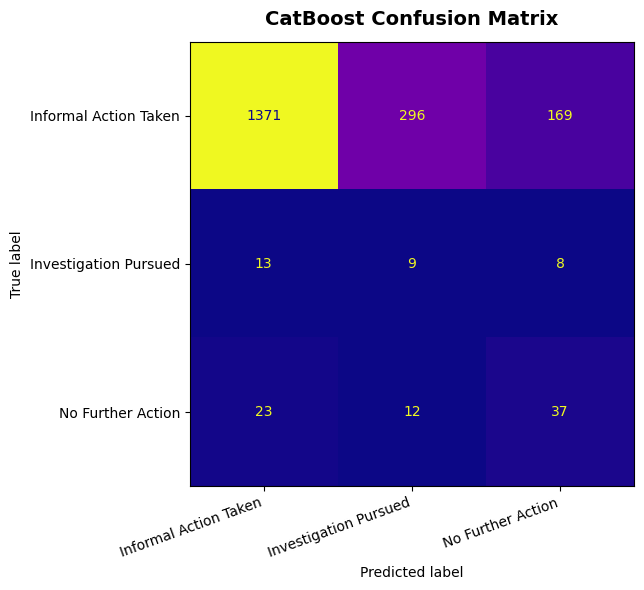

Confusion Matrix:
                        Informal Action Taken  Investigation Pursued  \
Informal Action Taken                   1371                    296   
Investigation Pursued                     13                      9   
No Further Action                         23                     12   

                       No Further Action  
Informal Action Taken                169  
Investigation Pursued                  8  
No Further Action                     37  


In [19]:
# Evaluate CatBoost on test set
y_pred_cb = cb_train.predict(X_test).flatten()
cb_metrics = evaluate_model("CatBoost", y_test, y_pred_cb)

Feature Importance Summary (grouped by original feature):
         original_feature  importance
            incident_type     28.6770
        incident_category     17.2258
no_data_subjects_affected     14.4497
                data_type     13.8837
        data_subject_type     13.7599
     time_taken_to_report     12.0039


C:\Users\elsad\AppData\Local\Temp\ipykernel_19600\1707098509.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cb_feature_summary["original_feature"], rotation=45, ha='right')


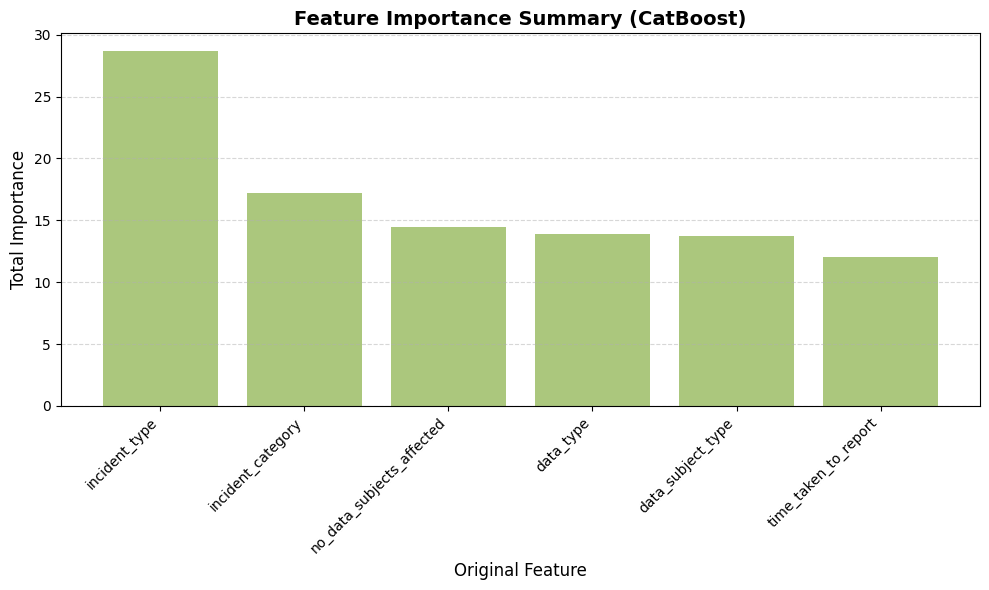

In [20]:
# CatBoost feature importance 
# Extract feature importance to see what columns the model is learning from
cb_importances_df = pd.DataFrame({
    "feature": X_train.columns, 
    "importance": cb_train.feature_importances_
}).sort_values(by="importance", ascending=False)

# add original feature column to importances df by applying the function to the feature names
cb_importances_df["original_feature"] = cb_importances_df["feature"].apply(get_original_feature)

# group by original feature and sum importance to see which features are important
cb_feature_summary = (
    cb_importances_df
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# table of feature importance summary
print("Feature Importance Summary (grouped by original feature):")
print(cb_feature_summary.round(4).to_string(index=False))

# bar chart of feature importance summary
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(cb_feature_summary["original_feature"], cb_feature_summary["importance"], color="#abc77d")
ax.set_title("Feature Importance Summary (CatBoost)", fontsize=14, fontweight='bold')
ax.set_xlabel("Original Feature", fontsize=12)
ax.set_ylabel("Total Importance", fontsize=12)
ax.set_xticklabels(cb_feature_summary["original_feature"], rotation=45, ha='right')
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [21]:
# Tests for CatBoost

# Test 1: predictions cover the full test set
assert len(y_pred_cb) == len(y_test), "Length of predictions does not match length of test labels"
print("1. Prediction count matches test label count")
print(f"\t{len(y_pred_cb)} predictions, {len(y_test)} test labels")

# Test 2: all predicted classes are valid known labels
assert set(y_pred_cb).issubset(set(CLASS_LABELS)), f"Predicted classes contain unknown labels: {set(y_pred_cb) - set(CLASS_LABELS)}"
print("2. All predicted classes are valid known labels")
print(f"\tSet of predicted classes: {set(y_pred_cb)}")

# Test 3: feature importances sum to approximately 1
assert abs(cb_importances_df["importance"].sum() - 100.0) < 1e-3, "Feature importances do not sum to approximately 100"
print("3. Feature importances sum to approximately 100")
print(f"\tSum of feature importances: {cb_importances_df['importance'].sum():.6f}")

# Test 4: model was trained on correct number of features
assert cb_train.n_features_in_ == X_train.shape[1], f"Model was trained on {cb_train.n_features_in_} features but expected {X_train.shape[1]}"
print("4. Model was trained on the correct number of features")
print(f"\t{cb_train.n_features_in_} features in model, {X_train.shape[1]} features in training data")

# Test 5: CV macro F1 mean us above a naive baseline 
mean_cv_f1 = cb_cv_results["test_macro_f1"].mean()
assert mean_cv_f1 > 0.2, f"Mean CV macro F1 score {mean_cv_f1:.4f} is not above the naive baseline of 0.2"
print(f"5. Mean CV macro F1 score {mean_cv_f1:.4f} is above the naive baseline of 0.2")
print(f"\tCV macro F1 scores across folds: {cb_cv_results['test_macro_f1']}")

# Test 6: no data leakage, test set rows aren't in the training set
train_periods = set(zip(df_train["year"], df_train["quarter"]))
test_periods = set(zip(df_test["year"], df_test["quarter"]))
assert train_periods.isdisjoint(test_periods), f"Data leakage detected: overlapping periods in train and test sets: {train_periods.intersection(test_periods)}"
print("6. No data leakage detected between train and test sets")
print(f"\t{sorted(train_periods)} training periods, {sorted(test_periods)} test periods")

1. Prediction count matches test label count
	1938 predictions, 1938 test labels
2. All predicted classes are valid known labels
	Set of predicted classes: {'Informal Action Taken', 'No Further Action', 'Investigation Pursued'}
3. Feature importances sum to approximately 100
	Sum of feature importances: 100.000000
4. Model was trained on the correct number of features
	59 features in model, 59 features in training data
5. Mean CV macro F1 score 0.5007 is above the naive baseline of 0.2
	CV macro F1 scores across folds: [0.46677045 0.4927353  0.48414209 0.55352705 0.50655759]
6. No data leakage detected between train and test sets
	[(2021, 'Qtr 2'), (2021, 'Qtr 3'), (2021, 'Qtr 4'), (2022, 'Qtr 1'), (2022, 'Qtr 2'), (2022, 'Qtr 3'), (2022, 'Qtr 4'), (2023, 'Qtr 1'), (2023, 'Qtr 2'), (2023, 'Qtr 3'), (2023, 'Qtr 4'), (2024, 'Qtr 1'), (2024, 'Qtr 2'), (2024, 'Qtr 3'), (2024, 'Qtr 4')] training periods, [(2025, 'Qtr 1'), (2025, 'Qtr 2'), (2025, 'Qtr 3'), (2025, 'Qtr 4')] test periods


In [22]:
# Collecting all model metrics for comparison 
comparison_df = pd.DataFrame([rf_metrics, cb_metrics]).set_index("model")
print(f"\nModel Comparison:\n {comparison_df.round(4).to_string()}")   

cv_comparison_df = pd.DataFrame({
    "Random Forest": {
        "CV Accuracy Mean" : rf_cv_results["test_accuracy"].mean(),
        "CV Macro F1 Mean" : rf_cv_results["test_macro_f1"].mean(),
        "CV Precision Mean": rf_cv_results["test_precision"].mean(),
        "CV Recall Mean"   : rf_cv_results["test_recall"].mean(),
        "CV Macro F1 Std"  : rf_cv_results["test_macro_f1"].std(),
    },
    "CatBoost": {
        "CV Accuracy Mean" : cb_cv_results["test_accuracy"].mean(),
        "CV Macro F1 Mean" : cb_cv_results["test_macro_f1"].mean(),
        "CV Precision Mean": cb_cv_results["test_precision"].mean(),
        "CV Recall Mean"   : cb_cv_results["test_recall"].mean(),
        "CV Macro F1 Std"  : cb_cv_results["test_macro_f1"].std(),
    }
}).round(4)

print(f"\nCross Validation Comparison:")
print(cv_comparison_df.to_string())



Model Comparison:
                accuracy  macro_f1  precision  recall
model                                               
Random Forest    0.8039    0.3780     0.3786  0.4224
CatBoost         0.7312    0.3854     0.3919  0.5202

Cross Validation Comparison:
                   Random Forest  CatBoost
CV Accuracy Mean          0.7365    0.7082
CV Macro F1 Mean          0.4602    0.5007
CV Precision Mean         0.4698    0.5049
CV Recall Mean            0.4708    0.5717
CV Macro F1 Std           0.0273    0.0294


Per-class F1 Scores:
                       Random Forest  CatBoost
Informal Action Taken         0.8940    0.8455
Investigation Pursued         0.0265    0.0519
No Further Action             0.2133    0.2587


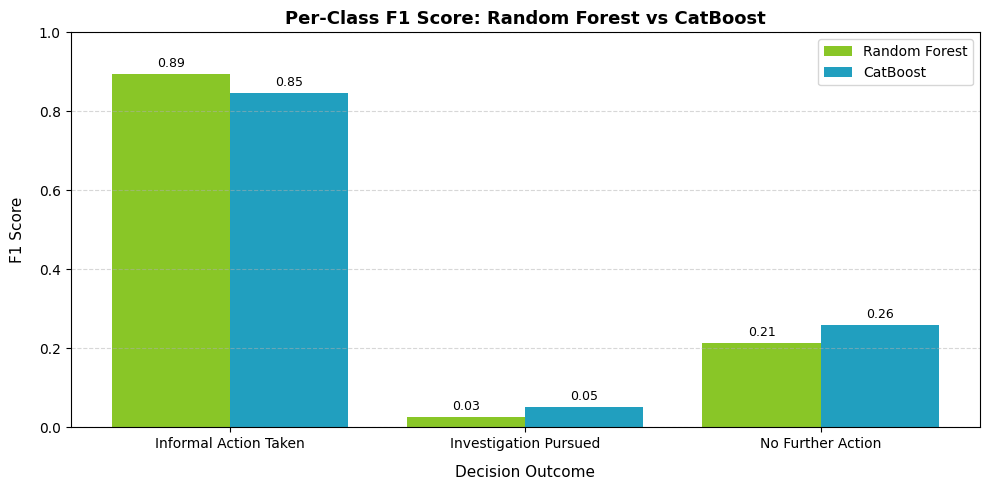

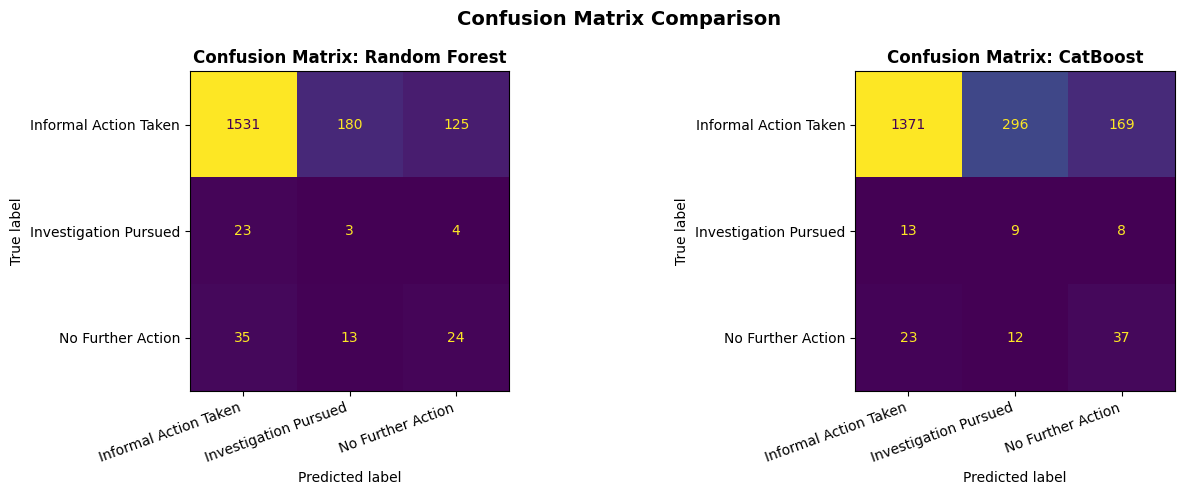


Random Forest Confusion Matrix:
                       Informal Action Taken  Investigation Pursued  No Further Action
Informal Action Taken                   1531                    180                125
Investigation Pursued                     23                      3                  4
No Further Action                         35                     13                 24

CatBoost Confusion Matrix:
                       Informal Action Taken  Investigation Pursued  No Further Action
Informal Action Taken                   1371                    296                169
Investigation Pursued                     13                      9                  8
No Further Action                         23                     12                 37


In [23]:
# Per-class F1 scores
rf_f1_per_class = f1_score(y_test, y_pred_rf, labels=CLASS_LABELS, average=None, zero_division=0)
cb_f1_per_class = f1_score(y_test, y_pred_cb, labels=CLASS_LABELS, average=None, zero_division=0)

f1_comparison = pd.DataFrame({
    "Random Forest": rf_f1_per_class,
    "CatBoost"     : cb_f1_per_class,
}, index=CLASS_LABELS)

print(f"Per-class F1 Scores:\n{f1_comparison.round(4).to_string()}")

# Per class F1 score bar chart comparison
x = np.arange(len(CLASS_LABELS))
width = 0.4
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, rf_f1_per_class, width, label="Random Forest", color="#89c627")
bars2 = ax.bar(x + width/2, cb_f1_per_class, width, label="CatBoost", color="#219fbf")

ax.set_title("Per-Class F1 Score: Random Forest vs CatBoost", fontsize=13, fontweight="bold")
ax.set_xlabel("Decision Outcome", fontsize=11, labelpad=10)
ax.set_ylabel("F1 Score", fontsize=11, labelpad=10)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_LABELS)
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# Side by side confusion matrix comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title in zip(axes, [y_pred_rf, y_pred_cb], ["Random Forest", "CatBoost"]):
    cm = confusion_matrix(y_test, y_pred, labels=CLASS_LABELS)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
    disp.plot(cmap="viridis", ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix: {title}", fontsize=12, fontweight="bold")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")

plt.suptitle("Confusion Matrix Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# confusion matrix values in table format for easier comparison
for y_pred, title in zip([y_pred_rf, y_pred_cb], ["Random Forest", "CatBoost"]):
    cm = confusion_matrix(y_test, y_pred, labels=CLASS_LABELS)
    cm_df = pd.DataFrame(cm, index=CLASS_LABELS, columns=CLASS_LABELS)
    print(f"\n{title} Confusion Matrix:\n{cm_df.round(4).to_string()}")

Feature Importance Comparison (normalised to 0-1):
                           Random Forest  CatBoost
group                                             
incident_type                     0.2773    0.2868
data_subject_type                 0.1821    0.1376
data_type                         0.1773    0.1388
no_data_subjects_affected         0.1430    0.1445
time_taken_to_report              0.1242    0.1200
incident_category                 0.0962    0.1723


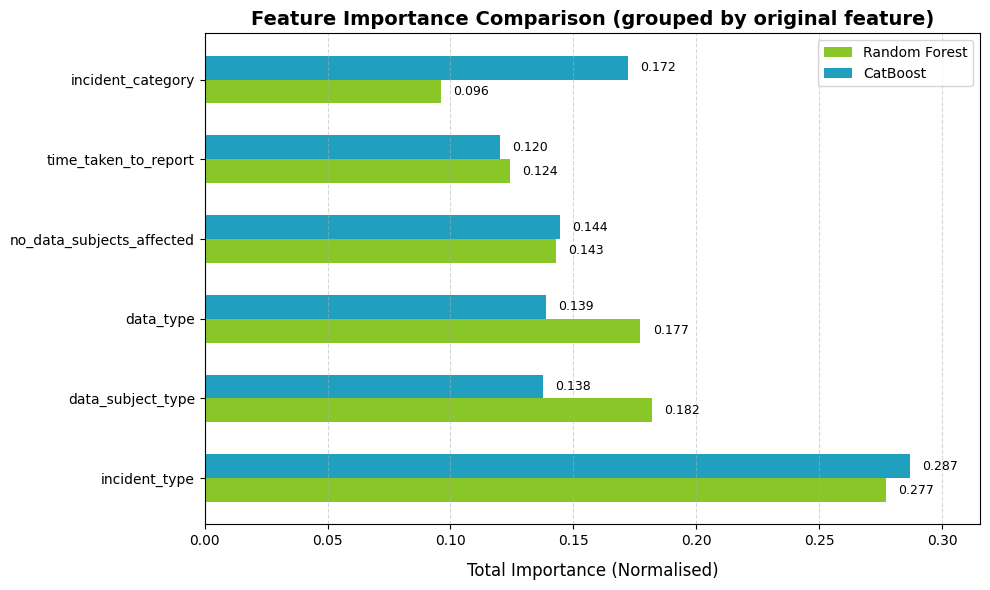

In [24]:
# RF importance grouped
rf_importance = pd.DataFrame({
    "feature"   : X_train.columns,
    "importance": rf_final.feature_importances_
})
rf_importance["group"] = rf_importance["feature"].apply(get_original_feature)
rf_grouped = rf_importance.groupby("group")["importance"].sum().sort_values(ascending=False)

# CatBoost importance grouped (corrected)
cb_importance = pd.DataFrame({
    "feature"   : X_train.columns,
    "importance": cb_train.get_feature_importance()
})
cb_importance["group"] = cb_importance["feature"].apply(get_original_feature)

# Normalise CatBoost to 0-1 scale to match RF for fair visual comparison
cb_grouped = cb_importance.groupby("group")["importance"].sum()
cb_grouped = (cb_grouped / cb_grouped.sum()).sort_values(ascending=False)

# Align both on the same feature order (RF order)
all_features = rf_grouped.index.tolist()
imp_comparison = pd.DataFrame({
    "Random Forest": rf_grouped.reindex(all_features),
    "CatBoost": cb_grouped.reindex(all_features),
}).fillna(0)

print("Feature Importance Comparison (normalised to 0-1):")
print(imp_comparison.round(4).to_string())

# Grouped horizontal bar chart
x = np.arange(len(all_features))
width = 0.3
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.barh(x - width/2, imp_comparison["Random Forest"], height=width, label="Random Forest", color="#89c627")
bars2 = ax.barh(x + width/2, imp_comparison["CatBoost"], height=width, label="CatBoost", color="#219fbf")

ax.set_title("Feature Importance Comparison (grouped by original feature)", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Importance (Normalised)", fontsize=12, labelpad=10)
ax.set_xlim(0, max(imp_comparison.max()) * 1.1)
ax.set_yticks(x)
ax.set_yticklabels(all_features)
ax.legend()
ax.grid(axis="x", linestyle="--", alpha=0.5)

for bar in bars1:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.3f}", va="center", fontsize=9)
for bar in bars2:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.3f}", va="center", fontsize=9)  
plt.tight_layout()
plt.show()

In [25]:
# Cluster feature matrix
X_cluster = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y_cluster = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

# Non-encoded cluster
df_cluster = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)
mlb_cols = [c for c in X_cluster.columns if "__" in c]
X_cluster_kmodes = pd.concat([
    df_cluster[CATEGORICAL_COLS].reset_index(drop=True),
    X_cluster[mlb_cols].reset_index(drop=True)
], axis=1)

print(f"Cluster matrix shape: {X_cluster.shape}")
print(f"Cluster target shape: {y_cluster.shape}")
print(f"Class distribution in cluster data:\n{y_cluster.value_counts()}")

print(f"\nKModes Cluster matrix shape: {X_cluster_kmodes.shape}")
print(X_cluster_kmodes.head(3).to_string())
print(f"MLB Columns: {len(mlb_cols)}")
print(f"Categorical Columns: {len(CATEGORICAL_COLS)}")

assert X_cluster_kmodes.isnull().sum().sum() == 0, "Nulls found in Kmodes cluster"
print("\nNo null found in Kmodes cluster")


Cluster matrix shape: (9250, 59)
Cluster target shape: (9250,)
Class distribution in cluster data:
decision_taken
Informal Action Taken    7670
No Further Action         982
Investigation Pursued     598
Name: count, dtype: int64

KModes Cluster matrix shape: (9250, 29)
  incident_category                                              incident_type no_data_subjects_affected  time_taken_to_report  data_subject_type__Children  data_subject_type__Customers or prospective customers  data_subject_type__Employees  data_subject_type__Patients  data_subject_type__Students  data_subject_type__Subscribers  data_subject_type__Unknown  data_subject_type__Users  data_subject_type__Vulnerable adults  data_type__Basic personal identifiers  data_type__Criminal convictions or offences  data_type__Data revealing racial or ethnic origin  data_type__Economic and financial data  data_type__Gender Reassignment Data  data_type__Genetic or biometric data  data_type__Health data  data_type__Identification data 

In [26]:
# Kmodes with categorical values instead of encoded features
kmodes_cat_costs = []
kmodes_cat_silhouette = []

for k in range(2, 11):
    km_final = KModes(n_clusters=k, init="Huang", n_init=10, random_state=RANDOM_STATE)
    labels = km_final.fit_predict(X_cluster_kmodes)
    kmodes_cat_costs.append(km_final.cost_)
    
    sil = silhouette_score(X_cluster, labels, metric="hamming")
    kmodes_cat_silhouette.append(sil)
    print(f"K={k}: Cost={km_final.cost_}, Silhouette={sil:.4f}")

K=2: Cost=30465.0, Silhouette=0.2622
K=3: Cost=28094.0, Silhouette=0.1924
K=4: Cost=26822.0, Silhouette=0.1475
K=5: Cost=25874.0, Silhouette=0.0748
K=6: Cost=24354.0, Silhouette=0.1121
K=7: Cost=23727.0, Silhouette=0.1106
K=8: Cost=23127.0, Silhouette=0.0827
K=9: Cost=22081.0, Silhouette=0.1004
K=10: Cost=22530.0, Silhouette=0.0814


In [27]:
# Kmodes, elbow and silhouette analysis to determine optimal number of clusters

kmodes_costs = []
kmodes_silhouette = []

for k in range(2, 11):
    km = KModes(n_clusters=k, init="Huang", n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_cluster)
    kmodes_costs.append(km.cost_)
    
    sil = silhouette_score(X_cluster, labels, metric="hamming")
    kmodes_silhouette.append(sil)
    print(f"K={k}: Cost={km.cost_}, Silhouette={sil:.4f}")

K=2: Cost=39299.0, Silhouette=0.2796
K=3: Cost=37016.0, Silhouette=0.1679
K=4: Cost=35405.0, Silhouette=0.1490
K=5: Cost=32072.0, Silhouette=0.2190
K=6: Cost=33401.0, Silhouette=0.1060
K=7: Cost=29955.0, Silhouette=0.2061
K=8: Cost=28881.0, Silhouette=0.1508
K=9: Cost=28759.0, Silhouette=0.2227
K=10: Cost=27595.0, Silhouette=0.1650


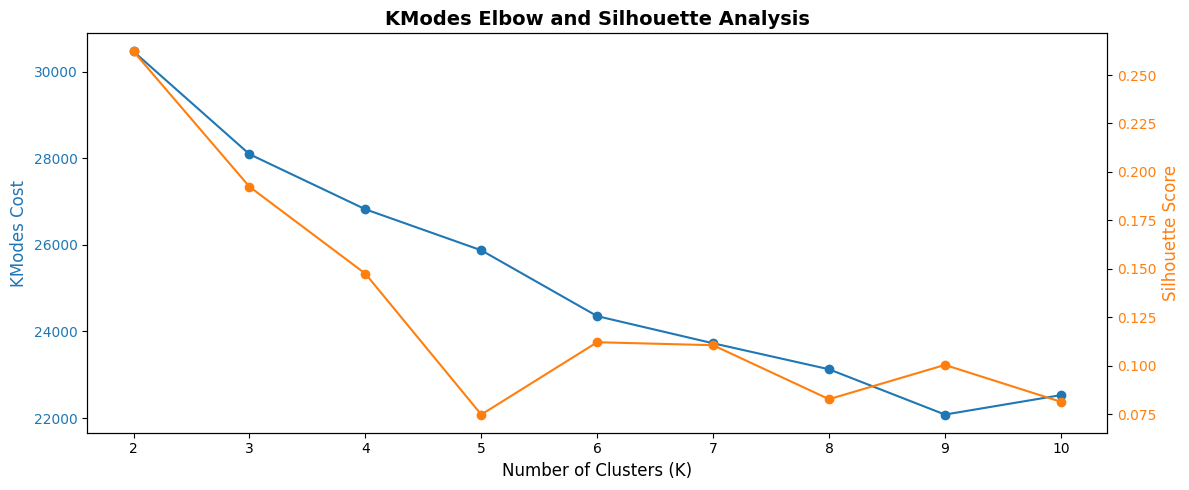

In [28]:
# Elbow & Silhouette plots
fig, ax1 = plt.subplots(figsize=(12, 5))
color = "tab:blue"
ax1.set_xlabel("Number of Clusters (K)", fontsize=12)
ax1.set_ylabel("KModes Cost", color=color, fontsize=12)
ax1.plot(range(2, 11), kmodes_cat_costs, marker="o", color=color)
ax1.tick_params(axis="y", labelcolor=color)
ax2 = ax1.twinx()
color = "tab:orange"
ax2.set_ylabel("Silhouette Score", color=color, fontsize=12)
ax2.plot(range(2, 11), kmodes_cat_silhouette, marker="o", color=color)
ax2.tick_params(axis="y", labelcolor=color)
plt.title("KModes Elbow and Silhouette Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [29]:
# KMeans clustering
kmeans_inertia = []
kmeans_silhouette = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_cluster)
    kmeans_inertia.append(km.inertia_)
    
    sil = silhouette_score(X_cluster, labels, metric="euclidean")
    kmeans_silhouette.append(sil)
    print(f"K={k}: Inertia={km.inertia_}, Silhouette={sil:.4f}")

K=2: Inertia=32109.278124106502, Silhouette=0.1475
K=3: Inertia=29783.649528794085, Silhouette=0.1431
K=4: Inertia=28269.7720608097, Silhouette=0.1017
K=5: Inertia=26616.64295125559, Silhouette=0.1229
K=6: Inertia=25176.538453679255, Silhouette=0.1467
K=7: Inertia=24187.620261561526, Silhouette=0.1556
K=8: Inertia=23544.698151723835, Silhouette=0.1478
K=9: Inertia=22908.17351525074, Silhouette=0.1424
K=10: Inertia=22520.414716688796, Silhouette=0.1429


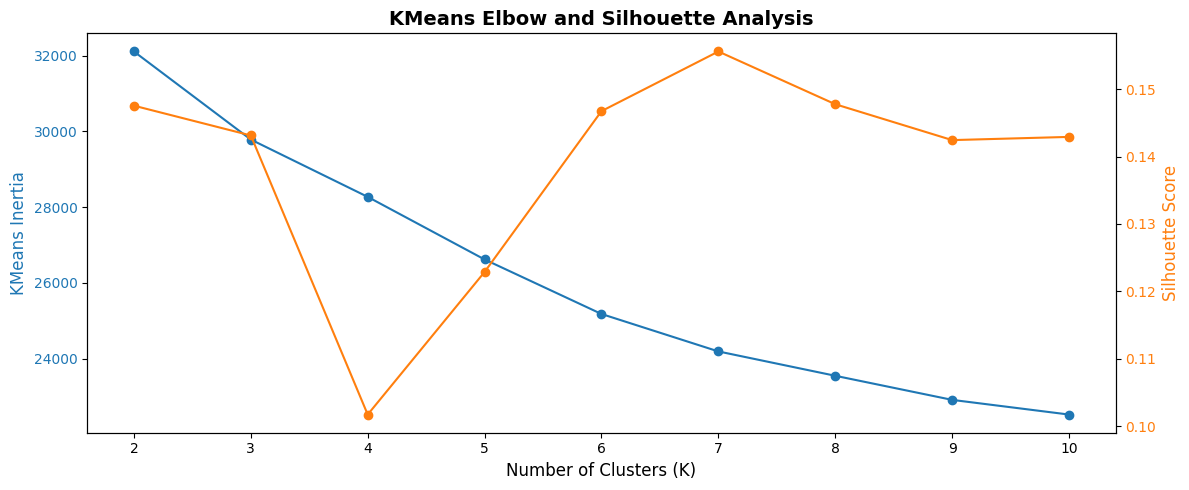

In [30]:

# Elbow & Silhouette plots for KMeans
fig, ax1 = plt.subplots(figsize=(12, 5))
color = "tab:blue"
ax1.set_xlabel("Number of Clusters (K)", fontsize=12)
ax1.set_ylabel("KMeans Inertia", color=color, fontsize=12)
ax1.plot(range(2, 11), kmeans_inertia, marker="o", color=color)
ax1.tick_params(axis="y", labelcolor=color)
ax2 = ax1.twinx()
color = "tab:orange"
ax2.set_ylabel("Silhouette Score", color=color, fontsize=12)
ax2.plot(range(2, 11), kmeans_silhouette, marker="o", color=color)
ax2.tick_params(axis="y", labelcolor=color)
plt.title("KMeans Elbow and Silhouette Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [31]:
# Final Kmodes clustering with chosen K

final_kmodes = 3 #because of the decision taken outcomes 
kmodes_final = KModes(n_clusters=final_kmodes, init="Huang", n_init=10, random_state=RANDOM_STATE)
kmodes_labels = kmodes_final.fit_predict(X_cluster_kmodes)
print(f"Final KModes clustering with K={final_kmodes}")
print(f"\nCluster sizes:\n{pd.Series(kmodes_labels).value_counts()}")
print(f"\nCluster centroids:\n{kmodes_final.cluster_centroids_}")
print(f"\nFinal Cost: {kmodes_final.cost_}")
unique_clusters, cluster_counts = np.unique(kmodes_labels, return_counts=True)
for cluster, count in zip(unique_clusters, cluster_counts):
    print(f"\tCluster {cluster}: {count} incidents ({count/len(kmodes_labels)*100:.1f}%)")
    
# results suggest clustering for this is pointless

Final KModes clustering with K=3

Cluster sizes:
1    4926
0    2745
2    1579
Name: count, dtype: int64

Cluster centroids:
[['Non Cyber' 'Data emailed to incorrect recipient' '1 to 9'
  '24 hours to 72 hours' '0' '0' '0' '0' '0' '0' '0' '0' '0' '1' '0' '0'
  '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0']
 ['Non Cyber' 'Other non-cyber incident' '1 to 9' '24 hours to 72 hours'
  '0' '0' '0' '1' '0' '0' '0' '0' '0' '1' '0' '0' '0' '0' '0' '1' '0' '0'
  '0' '0' '0' '0' '0' '0' '0']
 ['Non Cyber' 'Other non-cyber incident' '1 to 9' 'Less than 24 hours'
  '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0'
  '0' '0' '0' '0' '0' '0' '1']]

Final Cost: 28094.0
	Cluster 0: 2745 incidents (29.7%)
	Cluster 1: 4926 incidents (53.3%)
	Cluster 2: 1579 incidents (17.1%)


Cross tab counts:
decision_taken  Informal Action Taken  Investigation Pursued  No Further Action   All
cluster                                                                              
0                                2402                    111                232  2745
1                                4148                    358                420  4926
2                                1120                    129                330  1579
All                              7670                    598                982  9250
Cross tab proportions:
decision_taken  Informal Action Taken  Investigation Pursued  No Further Action
cluster                                                                        
0                              0.8750                 0.0404             0.0845
1                              0.8421                 0.0727             0.0853
2                              0.7093                 0.0817             0.2090
All                            0.8292      

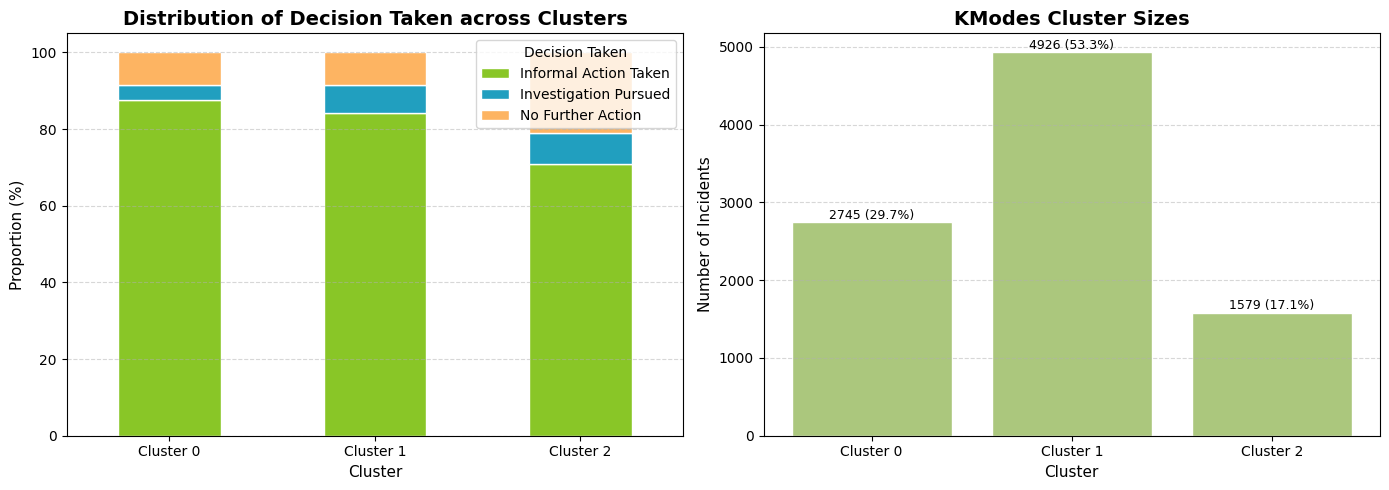

In [32]:
# Analysis of the Kmodes clusters to see if they provide proof of groupings

df_kmodes_analysis = df_cluster[CATEGORICAL_COLS + ["decision_taken"]].copy()
df_kmodes_analysis["cluster"] = kmodes_labels

# Cross tab of cluster vs decision taken (counts)
kmodes_cross_tab = pd.crosstab(df_kmodes_analysis["cluster"], df_kmodes_analysis["decision_taken"], margins=True)
print("Cross tab counts:")
print(kmodes_cross_tab.to_string())

# Cross tab of cluster vs decision taken (proportions)
kmodes_cross_tab_prop = pd.crosstab(df_kmodes_analysis["cluster"], df_kmodes_analysis["decision_taken"], normalize="index", margins=True)
print("Cross tab proportions:")
print(kmodes_cross_tab_prop.round(4).to_string())

# Dominant category per cluster
kmodes_cluster_summary = (
    df_kmodes_analysis
    .groupby("cluster")[CATEGORICAL_COLS]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "None")
)
print("Dominant category per cluster:")
print(kmodes_cluster_summary.to_string())

# Visualise distribution of decision taken across clusters
kmodes_decision_dist = pd.crosstab(
    df_kmodes_analysis["cluster"],
    df_kmodes_analysis["decision_taken"],
    normalize="index"
).mul(100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
kmodes_decision_dist.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    color=["#89c627", "#219fbf", "#fdb462"],
    edgecolor="white"
)
axes[0].set_title("Distribution of Decision Taken across Clusters", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Cluster", fontsize=11)
axes[0].set_ylabel("Proportion (%)", fontsize=11)
axes[0].legend(title="Decision Taken", loc="upper right")
axes[0].set_xticklabels([f"Cluster {i}" for i in range(final_kmodes)], rotation=0)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# Cluster size bar chart
cluster_sizes = pd.Series(
    cluster_counts,
    index=[f"Cluster {i}" for i in range(final_kmodes)]
)
axes[1].bar(cluster_sizes.index, cluster_sizes.values, color="#abc77d", edgecolor="white")
axes[1].set_title("KModes Cluster Sizes", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Cluster", fontsize=11)
axes[1].set_ylabel("Number of Incidents", fontsize=11)  
axes[1].grid(axis="y", linestyle="--", alpha=0.5)
for i, count in enumerate(cluster_sizes.values):
    axes[1].text(i, count + 5, f"{count} ({count/len(df_kmodes_analysis)*100:.1f}%)", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

In [33]:
# Check the cluster purity in regard to the target variable 
kmodes_purity = (
    df_kmodes_analysis
    .groupby("cluster")["decision_taken"]
    .agg(lambda x: x.value_counts(normalize=True).max())
)
print("KModes Cluster Purity (proportion of dominant class in each cluster):")
print(kmodes_purity.round(4).to_string())

# Silhouette score for the final KModes clustering
final_silhouette = silhouette_score(X_cluster, kmodes_labels, metric="hamming")
print(f"Final KModes Silhouette Score: {final_silhouette:.4f}")

# Final cost for the final KModes clustering
kmodes_cost = kmodes_final.cost_
print(f"Final KModes Cost: {kmodes_cost}")   

KModes Cluster Purity (proportion of dominant class in each cluster):
cluster
0    0.8750
1    0.8421
2    0.7093
Final KModes Silhouette Score: 0.1924
Final KModes Cost: 28094.0


In [34]:
# Tests for Kmodes
# Test 1: correct number of clusters made
assert len(np.unique(kmodes_labels)) == final_kmodes, f"Expected {final_kmodes} clusters but found {len(np.unique(kmodes_labels))}"
print("1. Correct number of clusters formed")
print(f"\tExpected clusters: {final_kmodes}, Unique clusters found: {len(np.unique(kmodes_labels))}")

# Test 2: every row has been assigned a cluster label
assert len(kmodes_labels) == len(X_cluster_kmodes), f"Number of cluster labels {len(kmodes_labels)} does not match number of rows in cluster data {len(X_cluster_kmodes)}"
print("2. Every row has been assigned a cluster label")
print(f"\tNumber of cluster labels: {len(kmodes_labels)}, Number of rows in cluster data: {len(X_cluster_kmodes)}")

# Tests 3: no empty clusters
for cluster in np.unique(kmodes_labels):
    count = np.sum(kmodes_labels == cluster)
    assert count > 0, f"Cluster {cluster} is empty with 0 samples"
print("3. No empty clusters found")
for cluster in np.unique(kmodes_labels):
    count = np.sum(kmodes_labels == cluster)
    print(f"\tCluster {cluster}: {count} samples")
    
# Test 4: cluster purity is above naive baseline 
assert kmodes_purity.mean() > 0.80, f"KModes cluster purity {kmodes_purity.mean():.4f} is not above the naive baseline of 0.80"
print(f"4. KModes cluster purity {kmodes_purity.mean():.4f} is above the naive baseline of 0.80")
print(f"\tKModes cluster purity: {kmodes_purity.mean():.4f}")

# Test 5: matrix has correct number of columns
expected_cols = len(CATEGORICAL_COLS) + len(mlb_cols)
assert X_cluster_kmodes.shape[1] == expected_cols, f"Expected {expected_cols} columns in KModes cluster matrix but found {X_cluster_kmodes.shape[1]}"
print("5. KModes cluster matrix has the correct number of columns")
print(f"\tExpected columns: {expected_cols}, Found columns: {X_cluster_kmodes.shape[1]}")


1. Correct number of clusters formed
	Expected clusters: 3, Unique clusters found: 3
2. Every row has been assigned a cluster label
	Number of cluster labels: 9250, Number of rows in cluster data: 9250
3. No empty clusters found
	Cluster 0: 2745 samples
	Cluster 1: 4926 samples
	Cluster 2: 1579 samples
4. KModes cluster purity 0.8088 is above the naive baseline of 0.80
	KModes cluster purity: 0.8088
5. KModes cluster matrix has the correct number of columns
	Expected columns: 29, Found columns: 29


In [35]:
# Kmeans final clustering with chosen K
final_kmeans = 2

kmeans_final = KMeans(n_clusters=final_kmeans, init='k-means++', n_init=10, random_state=RANDOM_STATE)
kmeans_labels = kmeans_final.fit_predict(X_cluster)

print(f"Final KMeans clustering with K={final_kmeans}")
print(f"\nCluster sizes:\n{pd.Series(kmeans_labels).value_counts()}")
print(f"\nCluster centroids:\n{kmeans_final.cluster_centers_}")

print(f"\nFinal Inertia: {kmeans_final.inertia_}")
unique_clusters, cluster_counts = np.unique(kmeans_labels, return_counts=True)
for cluster, count in zip(unique_clusters, cluster_counts):
    print(f"\tCluster {cluster}: {count} incidents ({count/len(kmeans_labels)*100:.1f}%)")

Final KMeans clustering with K=2

Cluster sizes:
0    6277
1    2973
Name: count, dtype: int64

Cluster centroids:
[[ 1.00987576e-01  3.24944250e-02  1.00350430e-01  8.63810131e-01
   5.41573750e-03  1.59286397e-03  4.38037592e-02  3.53615801e-02
   7.05638738e-02  8.58872252e-01  1.29021982e-02  4.30073272e-02
   1.86365084e-02  8.76075183e-03  9.87575661e-03  8.70500159e-01
   1.84772220e-02  2.94679834e-02  1.35393437e-02  1.59286397e-03
   1.19464798e-02  2.10258044e-02  2.19815228e-02  7.96431985e-04
   1.05471187e-15  4.76266327e-02  9.52373367e-01  3.18572794e-03
   1.43357757e-03  1.73940745e-01  3.63172985e-02  1.21216948e-01
   4.77859191e-04  3.47244345e-02  1.68843581e-02  3.04237018e-02
   6.37145588e-04  9.23861102e-03  1.24243390e-02  9.27046830e-02
   1.27429118e-03  9.39789742e-03  6.84931507e-03  1.88435808e-01
   1.01943294e-02  1.56100669e-02  1.89072953e-01  4.55559095e-02
   7.28416693e-01  1.13411915e-01  6.35552724e-02  3.82287353e-03
   1.09907614e-02  3.360942

Cross tab counts:
decision_taken  Informal Action Taken  Investigation Pursued  No Further Action   All
cluster                                                                              
0                                5388                    417                472  6277
1                                2282                    181                510  2973
All                              7670                    598                982  9250
Cross tab proportions:
decision_taken  Informal Action Taken  Investigation Pursued  No Further Action
cluster                                                                        
0                              0.8584                 0.0664             0.0752
1                              0.7676                 0.0609             0.1715
All                            0.8292                 0.0646             0.1062
Dominant category per cluster:
        incident_category             incident_type no_data_subjects_affected  time_taken_to_repor

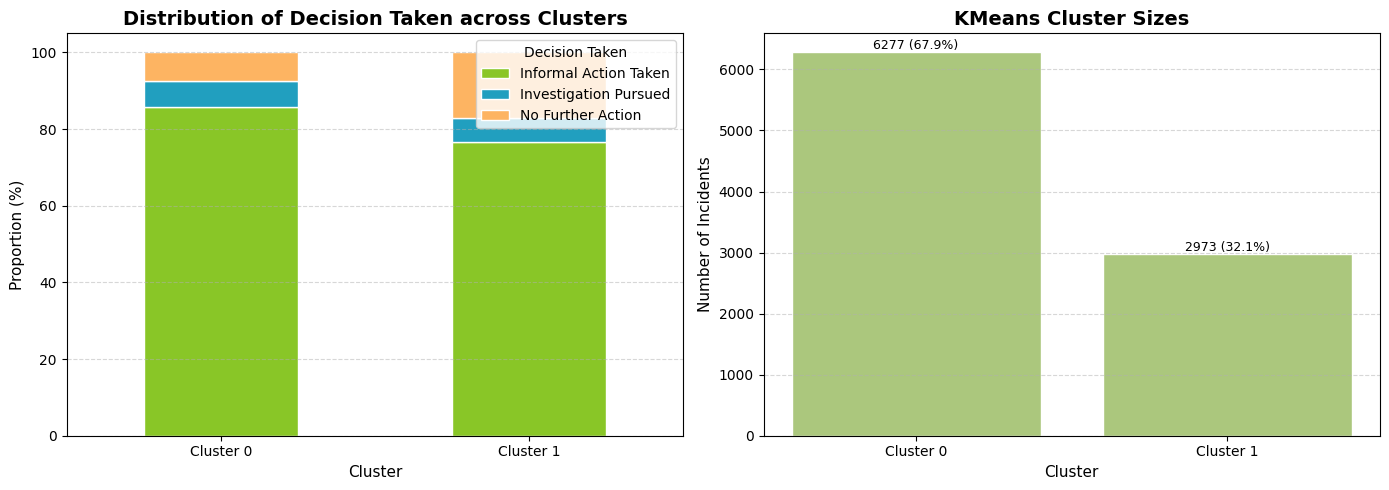

In [36]:
# Kmeans Analysis of the clusters to see if they provide proof of groupings

df_kmeans_analysis = df_cluster[CATEGORICAL_COLS + ["decision_taken"]].copy()
df_kmeans_analysis["cluster"] = kmeans_labels

# Cross tab of cluster vs decision taken (counts)
kmeans_cross_tab = pd.crosstab(df_kmeans_analysis["cluster"], df_kmeans_analysis["decision_taken"], margins=True)
print("Cross tab counts:")
print(kmeans_cross_tab.to_string())

# Cross tab of cluster vs decision taken (proportions)
kmeans_cross_tab_prop = pd.crosstab(df_kmeans_analysis["cluster"], df_kmeans_analysis["decision_taken"], normalize="index", margins=True)
print("Cross tab proportions:")
print(kmeans_cross_tab_prop.round(4).to_string())

# Dominant category per cluster
kmeans_cluster_summary = (
    df_kmeans_analysis
    .groupby("cluster")[CATEGORICAL_COLS]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "None")
)
print("Dominant category per cluster:")
print(kmeans_cluster_summary.to_string())

# Visualise distribution of decision taken across clusters
kmeans_decision_dist = pd.crosstab(
    df_kmeans_analysis["cluster"],
    df_kmeans_analysis["decision_taken"],
    normalize="index"
).mul(100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
kmeans_decision_dist.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    color=["#89c627", "#219fbf", "#fdb462"],
    edgecolor="white"
)
axes[0].set_title("Distribution of Decision Taken across Clusters", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Cluster", fontsize=11)
axes[0].set_ylabel("Proportion (%)", fontsize=11)
axes[0].legend(title="Decision Taken", loc="upper right")
axes[0].set_xticklabels([f"Cluster {i}" for i in range(final_kmeans)], rotation=0)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# Cluster size bar chart
cluster_sizes = pd.Series(
    cluster_counts,
    index=[f"Cluster {i}" for i in range(final_kmeans)]
)
axes[1].bar(cluster_sizes.index, cluster_sizes.values, color="#abc77d", edgecolor="white")
axes[1].set_title("KMeans Cluster Sizes", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Cluster", fontsize=11)
axes[1].set_ylabel("Number of Incidents", fontsize=11)  
axes[1].grid(axis="y", linestyle="--", alpha=0.5)
for i, count in enumerate(cluster_sizes.values):
    axes[1].text(i, count + 5, f"{count} ({count/len(df_kmeans_analysis)*100:.1f}%)", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

In [37]:
# Kmeans cluster purity
kmeans_purity = (
    df_kmeans_analysis
    .groupby("cluster")["decision_taken"]
    .agg(lambda x: x.value_counts(normalize=True).max())
)   
print("KMeans Cluster Purity (proportion of dominant class in each cluster):")
print(kmeans_purity.round(4).to_string())

# Silhouette score for the final KMeans clustering
kmeans_silhouette = silhouette_score(X_cluster, kmeans_labels, metric="euclidean")
print(f"Final KMeans Silhouette Score: {kmeans_silhouette:.4f}")

# Final inertia for the final KMeans clustering
kmeans_inertia = kmeans_final.inertia_    
print(f"Final KMeans Inertia: {kmeans_inertia}")

KMeans Cluster Purity (proportion of dominant class in each cluster):
cluster
0    0.8584
1    0.7676


Final KMeans Silhouette Score: 0.1475
Final KMeans Inertia: 32109.278124106502


In [38]:
# Tests for Kmeans

# Test 1: correct number of clusters made
assert len(np.unique(kmeans_labels)) == final_kmeans, f"Expected {final_kmeans} clusters but found {len(np.unique(kmeans_labels))}"
print("1. Correct number of clusters formed")
print(f"\tExpected clusters: {final_kmeans}, Unique clusters found: {len(np.unique(kmeans_labels))}")

# Test 2: every row has been assigned a cluster label
assert len(kmeans_labels) == len(X_cluster), f"Number of cluster labels {len(kmeans_labels)} does not match number of rows in cluster data {len(X_cluster)}"
print("2. Every row has been assigned a cluster label") 
print(f"\tNumber of cluster labels: {len(kmeans_labels)}, Number of rows in cluster data: {len(X_cluster)}")

# Test 3: no empty clusters
for cluster in np.unique(kmeans_labels):
    count = np.sum(kmeans_labels == cluster)
    assert count > 0, f"Cluster {cluster} is empty with 0 samples"
print("3. No empty clusters found")
for cluster in np.unique(kmeans_labels):
    count = np.sum(kmeans_labels == cluster)
    print(f"\tCluster {cluster}: {count} samples")
    
# Test 4: cluster purity is above naive baseline
assert kmeans_purity.mean() > 0.80, f"KMeans cluster purity {kmeans_purity.mean():.4f} is not above the naive baseline of 0.80" 
print(f"4. KMeans cluster purity {kmeans_purity.mean():.4f} is above the naive baseline of 0.80")
print(f"\tKMeans cluster purity: {kmeans_purity.mean():.4f}")

# Test 5: matrix has correct number of columns
assert X_cluster.shape[1] == 59, f"Expected 59 columns in KMeans cluster matrix but found {X_cluster.shape[1]}" 
print("5. KMeans cluster matrix has the correct number of columns")
print(f"\tExpected columns: 59, Found columns: {X_cluster.shape[1]}")


1. Correct number of clusters formed
	Expected clusters: 2, Unique clusters found: 2
2. Every row has been assigned a cluster label
	Number of cluster labels: 9250, Number of rows in cluster data: 9250
3. No empty clusters found
	Cluster 0: 6277 samples
	Cluster 1: 2973 samples
4. KMeans cluster purity 0.8130 is above the naive baseline of 0.80
	KMeans cluster purity: 0.8130
5. KMeans cluster matrix has the correct number of columns
	Expected columns: 59, Found columns: 59


In [39]:
# Compare Kmodes and KMeans
final_kmodes_silhouette = silhouette_score(
    X_cluster, kmodes_labels, metric="hamming"
)

clustering_comparison = pd.DataFrame({
    "KModes": {
        "K": final_kmodes,
        "Cluster Purity": round(kmodes_purity.mean(), 4),
        "Silhouette Score": round(final_kmodes_silhouette, 4),
        "Cost": kmodes_cost
    },
    "KMeans": {
        "K": final_kmeans,
        "Cluster Purity": round(kmeans_purity.mean(), 4),
        "Silhouette Score": round(kmeans_silhouette, 4),
        "Inertia": kmeans_inertia
    }
})

print(f"Clustering Comparison:\n{clustering_comparison.to_string()}")

Clustering Comparison:
                      KModes        KMeans
K                     3.0000      2.000000
Cluster Purity        0.8088      0.813000
Silhouette Score      0.1924      0.147500
Cost              28094.0000           NaN
Inertia                  NaN  32109.278124


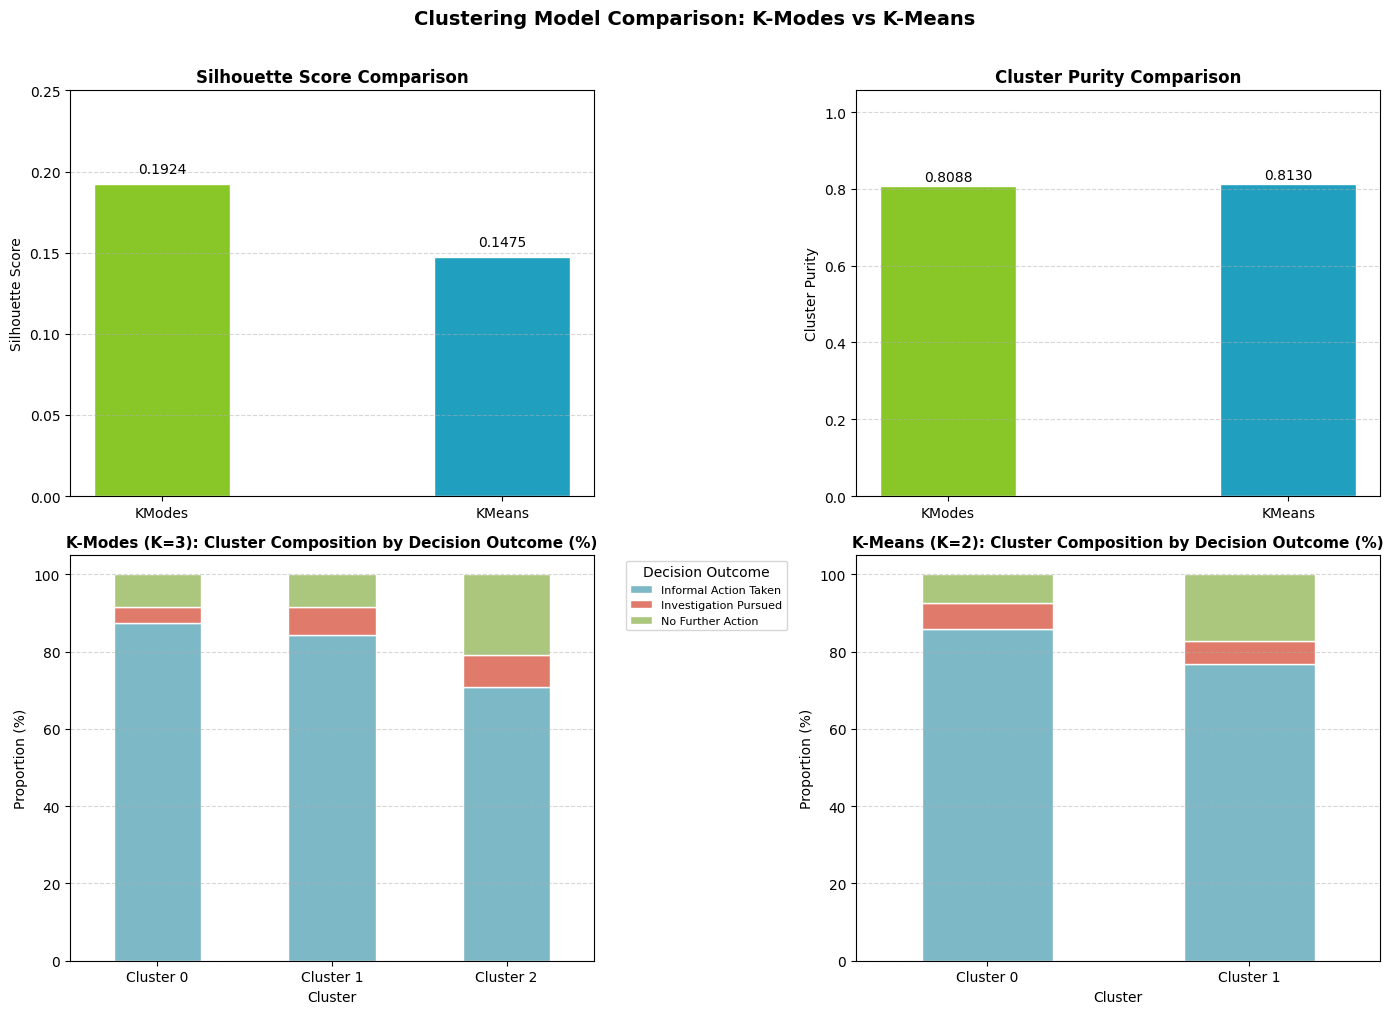

In [40]:
# Visual comparison of cluster purity and silhouette scores
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top row is silhouette and purity bar charts
cluster_metrics = {
    "Silhouette Score": {
        "KModes": final_kmodes_silhouette,
        "KMeans": kmeans_silhouette
    },
    "Cluster Purity": {
        "KModes": kmodes_purity.mean(),
        "KMeans": kmeans_purity.mean()
    }
}

for ax, (metric_name, values) in zip(axes[0], cluster_metrics.items()):
    models = list(values.keys())
    scores = list(values.values())
    colours = ["#89c627", "#219fbf"]
    bars = ax.bar(models, scores, color=colours, edgecolor="white", width=0.4)
    ax.set_title(f"{metric_name} Comparison", fontsize=12, fontweight="bold")
    ax.set_ylabel(metric_name)
    ax.set_ylim(0, max(scores) * 1.3)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.4f}",
            ha="center", va="bottom", fontsize=10
        )
        
# Bottom row is cluster composition stacked bar charts
for ax, (analysis_df, title, k) in zip(
    axes[1], [(df_kmodes_analysis, "K-Modes (K=3)", final_kmodes), (df_kmeans_analysis, "K-Means (K=2)", final_kmeans)]
):
    crosstab_plot = pd.crosstab(
        analysis_df["cluster"],
        analysis_df["decision_taken"],
        normalize="index"
    ).mul(100)

    crosstab_plot.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=["#7db8c7", "#e07b6b", "#abc77d"],
        edgecolor="white",
        legend=(title == "K-Modes (K=3)")   # only show legend on first chart
    )
    ax.set_title(f"{title}: Cluster Composition by Decision Outcome (%)", fontsize=11, fontweight="bold")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Proportion (%)")
    ax.set_xticklabels(
        [f"Cluster {i}" for i in range(k)], rotation=0
    )
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    if title == "K-Modes (K=3)":
        ax.legend(title="Decision Outcome", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)

plt.suptitle("Clustering Model Comparison: K-Modes vs K-Means", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [41]:
# Summary of cluster purity for both models

print("Per-Cluster Purity Breakdown:")
print("\nK-Modes:")
print(kmodes_purity.to_string(index=False))
print("\nK-Means:")
print(kmeans_purity.to_string(index=False))

# Summary of silhouette scores for both models
print(f"\nSilhouette Scores:\nKModes: {final_kmodes_silhouette:.4f}\nKMeans: {kmeans_silhouette:.4f}")

# Table comparing cluster composition for K-Modes and K-Means
kmodes_composition = pd.crosstab(
    df_kmodes_analysis["cluster"],
    df_kmodes_analysis["decision_taken"],
    normalize="index"
).mul(100).round(2)

kmeans_composition = pd.crosstab(
    df_kmeans_analysis["cluster"],
    df_kmeans_analysis["decision_taken"],
    normalize="index"
).mul(100).round(2)
composition_comparison = pd.concat(
    {
        "K-Modes": kmodes_composition,
        "K-Means": kmeans_composition
    },
    axis=0
)
print(f"Cluster Composition Comparison (proportion of decision outcomes within each cluster):\n{composition_comparison.to_string()}")


Per-Cluster Purity Breakdown:

K-Modes:
cluster
0.875046
0.842063
0.709310

K-Means:
cluster
0.858372
0.767575

Silhouette Scores:
KModes: 0.1924
KMeans: 0.1475
Cluster Composition Comparison (proportion of decision outcomes within each cluster):
decision_taken   Informal Action Taken  Investigation Pursued  No Further Action
        cluster                                                                 
K-Modes 0                        87.50                   4.04               8.45
        1                        84.21                   7.27               8.53
        2                        70.93                   8.17              20.90
K-Means 0                        85.84                   6.64               7.52
        1                        76.76                   6.09              17.15


0    Informal Action Taken
1    Informal Action Taken
2    Informal Action Taken
3    Informal Action Taken
4    Informal Action Taken
5    Informal Action Taken
6    Informal Action Taken
7    Informal Action Taken
8    Informal Action Taken
9    Informal Action Taken
Name: decision_taken, dtype: object

In [ ]:
# Hyper parameter tuning for CatBoost using GridSearchCV
# Learning rate, depth, iterations, l2 leaf regularization for CatBoost

cb_param_grid = {
    "learning_rate": [0.03, 0.05, 0.1],
    "depth": [6, 8, 10],
    "l2_leaf_reg": [3, 5, 7]
}

print("CatBoost GridSearchCV parameter grid:")
total_combinations = 1
for param, values in cb_param_grid.items():
    print(f"\t{param}: {values}")
    total_combinations *= len(values)

print(f"Total combinations: {total_combinations}")
print(f"Total model fits: {total_combinations * 5} (5-fold CV)")
print("Starting GridSearchCV for CatBoost")

tune_model = CatBoostClassifier(
    iterations=2000,
    loss_function="MultiClass",
    eval_metric="TotalF1:average=Macro",
    random_seed=RANDOM_STATE,
    early_stopping_rounds=50,
    verbose=False,
)

tscv = TimeSeriesSplit(n_splits=5)

cb_grid_search = tune_model.grid_search(
    cb_param_grid,
    X=X_train,
    y=y_train,
    cv=tscv,
    refit=False,
    shuffle=False,
    stratified=False,
    verbose=2,
)

# Results of the Grid Search
print(f"CatBoost GridSearchCV Results:")
print(f"Best parameters:")
    
# Compare the best CatBoost model from GridSearchCV with the default CatBoost model
'''
baseline_cb_cv_f1 = cb_cv_results["test_macro_f1"].mean()
best_cb_cv_f1 = cb_grid_search.best_score_
print(f"Baseline CatBoost CV Macro F1: {baseline_cb_cv_f1:.4f}")
print(f"Best CatBoost CV Macro F1 from GridSearchCV: {best_cb_cv_f1:.4f}")
improvement_cb_f1 = best_cb_cv_f1 - baseline_cb_cv_f1
print(f"Improvement in CV Macro F1: {improvement_cb_f1:.4f}")
'''

CatBoost GridSearchCV parameter grid:
	learning_rate: [0.03, 0.05, 0.1]
	depth: [6, 8, 10]
	l2_leaf_reg: [3, 5, 7]
Total combinations: 27
Total model fits: 135 (5-fold CV)
Starting GridSearchCV for CatBoost


c:\Users\elsad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:1262: UserWarning: The groups parameter is ignored by TimeSeriesSplit
  warnings.warn(


Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.3837547703
bestIteration = 45

0:	loss: 0.3837548	best: 0.3837548 (0)	total: 437ms	remaining: 11.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.3817282784
bestIteration = 29

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.3967609413
bestIteration = 99

2:	loss: 0.3967609	best: 0.3967609 (2)	total: 1.38s	remaining: 11s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.3844603672
bestIteration = 27

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.3821573491
bestIteration = 38

4:	loss: 0.3821573	best: 0.3967609 (2)	total: 2.03s	remaining: 8.93s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.3830208333
bestIteration = 8

Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.3844603672
bestIteration = 28

6:	loss: 0.3844604	best: 0.3967609 (2)	total: 2.57s	remaining: 7.35s
Stopped by overfitting detector  (

In [65]:
best_params = cb_grid_search["params"]
print(f"Best parameters: {best_params}")
best_cb_cv_results = pd.DataFrame(cb_grid_search["cv_results"])
print(best_cb_cv_results.round(4).to_string())

best_iter = best_cb_cv_results["test-TotalF1:average=Macro-mean"].idxmax()
train_f1 = best_cb_cv_results.loc[best_iter, "train-TotalF1:average=Macro-mean"]
test_f1 = best_cb_cv_results.loc[best_iter, "test-TotalF1:average=Macro-mean"]
print(f"Train F1: {train_f1:.4f}, Test F1: {test_f1:.4f}, Gap: {train_f1 - test_f1:.4f}")

print(f"Best iteration was {best_iter} of {len(best_cb_cv_results)} total")
print(f"Test F1 at iter 100: {best_cb_cv_results.loc[100, 'test-TotalF1:average=Macro-mean']:.4f}")
print(f"Test F1 at iter 500: {best_cb_cv_results.loc[min(500, len(best_cb_cv_results)-1), 'test-TotalF1:average=Macro-mean']:.4f}")
print(f"Test F1 at best:     {best_cb_cv_results.loc[best_iter, 'test-TotalF1:average=Macro-mean']:.4f}")


Best parameters: {'depth': 10, 'learning_rate': 0.1, 'l2_leaf_reg': 7}
     iterations  test-TotalF1:average=Macro-mean  test-TotalF1:average=Macro-std  train-TotalF1:average=Macro-mean  train-TotalF1:average=Macro-std  test-MultiClass-mean  test-MultiClass-std  train-MultiClass-mean  train-MultiClass-std
0             0                           0.4190                          0.0537                            0.5288                           0.0652                0.9941               0.0073                 0.9881                0.0060
1             1                           0.4214                          0.0517                            0.5283                           0.0688                0.9168               0.0112                 0.9034                0.0100
2             2                           0.4137                          0.0498                            0.5202                           0.0487                0.8540               0.0159                 0.8327        

In [ ]:
# Kmodes tuning with different K values and initialisation methods
kmodes_tuning_results = []
for init_method in ["Huang", "Cao"]:
    for n_init_val in [10, 20, 30]:
        km_check = KModes(
            n_clusters=final_kmodes,
            init=init_method,
            n_init=n_init_val,
            random_state=RANDOM_STATE
        )
        
        labels_check = km_check.fit_predict(X_cluster_kmodes)
        silhouette_check = silhouette_score(X_cluster, labels_check, metric="hamming")
        purity_check = (
            df_kmodes_analysis
            .assign(cluster=labels_check)
            .groupby("cluster")["decision_taken"]
            .agg(lambda x: x.value_counts(normalize=True).max())
            .mean()
        )
        
        kmodes_tuning_results.append({
            "init": init_method,
            "n_init": n_init_val,
            "cost": km_check.cost_,
            "silhouette_score": silhouette_check,
            "overall_purity": purity_check
        })
        
        print(f"Init={init_method}\nn_init={n_init_val}\nCost={km_check.cost_}\nSilhouette Score={silhouette_check:.4f}\nOverall Purity={purity_check:.4f}")
        
# Summary table of Kmodes tuning results
kmodes_tuning_df = pd.DataFrame(kmodes_tuning_results)
print(f"\nKModes Tuning Results:\n{kmodes_tuning_df.to_string(index=False)}")

# Select best config: lowest cost, highest silhouette
best_kmodes_config = kmodes_tuning_df.sort_values(by=["cost", "silhouette_score"], ascending=[True, False]).iloc[0]

BEST_KMODES_INIT = best_kmodes_config["init"]
BEST_KMODES_N_INIT = int(best_kmodes_config["n_init"])

print(f"Best Kmodes configuration:")
print(f"\tInit method: {BEST_KMODES_INIT}")
print(f"\tn_init: {BEST_KMODES_N_INIT}")


Init=Huang
n_init=10
Cost=28094.0
Silhouette Score=0.1924
Overall Purity=0.8088
Init=Huang
n_init=20
Cost=28094.0
Silhouette Score=0.1924
Overall Purity=0.8088
Init=Huang
n_init=30
Cost=28094.0
Silhouette Score=0.1924
Overall Purity=0.8088
Init=Cao
n_init=10
Cost=29085.0
Silhouette Score=0.2832
Overall Purity=0.7770
Init=Cao
n_init=20
Cost=29085.0
Silhouette Score=0.2832
Overall Purity=0.7770
Init=Cao
n_init=30
Cost=29085.0
Silhouette Score=0.2832
Overall Purity=0.7770

KModes Tuning Results:
 init  n_init    cost  silhouette_score  overall_purity
Huang      10 28094.0          0.192376        0.808806
Huang      20 28094.0          0.192376        0.808806
Huang      30 28094.0          0.192376        0.808806
  Cao      10 29085.0          0.283244        0.777009
  Cao      20 29085.0          0.283244        0.777009
  Cao      30 29085.0          0.283244        0.777009
Best Kmodes configuration:
	Init method: Huang
	n_init: 10


In [ ]:
cb_final = CatBoostClassifier(
    auto_class_weights="Balanced",
    random_state=RANDOM_STATE,
    verbose=0,
    depth=10,
    iterations=300,
    l2_leaf_reg=3,
    learning_rate=0.01
)

kmodes_final = KModes(
    n_clusters=final_kmodes,
    init=BEST_KMODES_INIT,
    n_init=BEST_KMODES_N_INIT,
    random_state=RANDOM_STATE
)

In [ ]:
# Evaluate tuned CatBoost with training set and test set

cb_tuned = CatBoostClassifier(
    auto_class_weights="Balanced",
    random_state=RANDOM_STATE,
    verbose=0,
    depth=12,
    iterations=200,
    l2_leaf_reg=5,
    learning_rate=0.01
)
cb_tuned.fit(X_train, y_train)
y_pred_cb_tuned = cb_tuned.predict(X_test).flatten()

cb_tuned_metrics = evaluate_model(model_name="CatBoost Tuned", y_true=y_test, y_pred=y_pred_cb_tuned)

# Evaluate baseline and tuned CatBoost side by side
cb_comparison_tuned = pd.DataFrame({
    "Baseline CatBoost": cb_metrics,
    "Tuned CatBoost": cb_tuned_metrics
})
print(f"CatBoost Performance Comparison:\n{cb_comparison_tuned.round(4).to_string()}")

# Per class F1 score comparison for baseline vs tuned CatBoost
cb_tuned_f1_per_class = f1_score(y_test, y_pred_cb_tuned, average=None, labels=CLASS_LABELS, zero_division=0)
cb_tuned_f1_comparison = pd.DataFrame({
    "Baseline CatBoost": cb_f1_per_class,
    "Tuned CatBoost": cb_tuned_f1_per_class
}, index=CLASS_LABELS)
print(f"CatBoost F1 Score Comparison per Class:\n{cb_tuned_f1_comparison.round(4).to_string()}")

NameError: name 'CatBoostClassifier' is not defined